# PPI-Cancer-Prediction Notebook

The idea of this project emerged when I found out that my newly discovered interest for networks could be combined with my rooted love for machine learning and biology to try and approach existing problems with new solutions and perspectives. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, PrecisionRecallDisplay

from xgboost import XGBClassifier
import shap

from scipy.stats import uniform, randint


c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Introduction

## 2. Data Exploration
### 2.1 Protein Aliases Dataset

In [2]:
df1 = pd.read_csv("C:\Local Programming Projects\ppi-cancer-prediction\data\9606.protein.aliases.v12.0.txt", sep='\t')
df1.head()

,#string_protein_id,alias,source
0,9606.ENSP00000000233,2B6H,Ensembl_PDB
1,9606.ENSP00000000233,2B6H,UniProt_DR_PDB
2,9606.ENSP00000000233,381,Ensembl_HGNC_entrez_id
3,9606.ENSP00000000233,381,KEGG_GENEID
4,9606.ENSP00000000233,381,KEGG_KEGGID_SHORT


In [3]:
print("Shape of dataset: ", df1.shape)
print("Column labels: ", df1.columns)
df1.info()
df1.describe()

Shape of dataset:  (3889207, 3)
Column labels:  Index(['#string_protein_id', 'alias', 'source'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 3889207 entries, 0 to 3889206
Data columns (total 3 columns):
 #   Column              Dtype
---  ------              -----
 0   #string_protein_id  str  
 1   alias               str  
 2   source              str  
dtypes: str(3)
memory usage: 89.0 MB


,#string_protein_id,alias,source
count,3889207,3889201,3889207
unique,19699,2553437,90
top,9606.ENSP00000354728,R-HSA-162582,Ensembl_EMBL
freq,92796,5472,487265


In [4]:
df1['#string_protein_id'].value_counts()

#string_protein_id
9606.ENSP00000354728    92796
9606.ENSP00000354982    78720
9606.ENSP00000355046    65409
9606.ENSP00000355265    54408
9606.ENSP00000354665    53281
                        ...  
9606.ENSP00000482263        9
9606.ENSP00000482855        8
9606.ENSP00000484918        8
9606.ENSP00000501013        8
9606.ENSP00000501098        8
Name: count, Length: 19699, dtype: int64

In [5]:
df1.isnull().sum().sort_values(ascending=False)

alias                 6
#string_protein_id    0
source                0
dtype: int64

### 2.2 Protein Links Dataset

In [6]:
df2 = pd.read_csv("C:\Local Programming Projects\ppi-cancer-prediction\data\9606.protein.links.v12.0.txt.gz", sep=' ')

In [7]:
print("Shape of dataset: ", df2.shape)
print("Column labels: ", df2.columns)
df2.info()
df2.describe()

Shape of dataset:  (13715404, 3)
Column labels:  Index(['protein1', 'protein2', 'combined_score'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 13715404 entries, 0 to 13715403
Data columns (total 3 columns):
 #   Column          Dtype
---  ------          -----
 0   protein1        str  
 1   protein2        str  
 2   combined_score  int64
dtypes: int64(1), str(2)
memory usage: 313.9 MB


,combined_score
count,1.371540e+07
mean,2.686240e+02
std,1.569828e+02
min,1.500000e+02
25%,1.710000e+02
50%,2.090000e+02
75%,2.980000e+02
max,9.990000e+02


In [8]:
df2.isnull().sum().sort_values(ascending=False)

protein1          0
protein2          0
combined_score    0
dtype: int64

In [9]:
df2['protein1'].value_counts().head()

protein1
9606.ENSP00000380070    9357
9606.ENSP00000494750    7773
9606.ENSP00000269305    7443
9606.ENSP00000451828    7179
9606.ENSP00000478887    7147
Name: count, dtype: int64

### 2.3 Cosmic Cancer Gene Census Dataset

In [10]:
df3 = pd.read_csv("C:\Local Programming Projects\ppi-cancer-prediction\data\Cosmic_CancerGeneCensus_v103_GRCh37.tsv", sep='\t')
df3.head(5)

,GENE_SYMBOL,NAME,COSMIC_GENE_ID,CHROMOSOME,GENOME_START,GENOME_STOP,CHR_BAND,SOMATIC,GERMLINE,TUMOUR_TYPES_SOMATIC,...,CANCER_SYNDROME,TISSUE_TYPE,MOLECULAR_GENETICS,ROLE_IN_CANCER,MUTATION_TYPES,TRANSLOCATION_PARTNER,OTHER_GERMLINE_MUT,OTHER_SYNDROME,TIER,SYNONYMS
0,A1CF,APOBEC1 complementation factor,COSG46891,10,52559169.0,52645435.0,10q11.23,y,n,melanoma,...,NaN,E,NaN,oncogene,Mis,NaN,n,NaN,2,"A1CF,ENSG00000148584.10,Q9NQ94,29974,ACF,ACF64..."
1,ABI1,abl interactor 1,COSG5120,10,27035522.0,27150016.0,10p12.1,y,n,AML,...,NaN,L,Dom,"TSG, fusion",T,KMT2A,n,NaN,1,"ABI1,ENSG00000136754.12,Q8IZP0,10006,ABI-1,E3B1"
2,ABL1,"ABL proto-oncogene 1, non-receptor tyrosine ki...",COSG4968,9,133589333.0,133763062.0,9q34.12,y,n,"CML, ALL, T-ALL",...,NaN,L,Dom,"oncogene, fusion","T, Mis","BCR, ETV6, NUP214",n,NaN,1,"ABL1,ENSG00000097007.13,P00519,25,JTK7,c-ABL,p150"
3,ABL2,"ABL proto-oncogene 2, non-receptor tyrosine ki...",COSG36573,1,179068462.0,179198819.0,1q25.2,y,n,AML,...,NaN,L,Dom,"oncogene, fusion",T,ETV6,n,NaN,1,"ABL2,ENSG00000143322.15,P42684,27,ARG"
4,ACKR3,atypical chemokine receptor 3,COSG38910,2,237476430.0,237491001.0,2q37.3,y,n,lipoma,...,NaN,M,Dom,"oncogene, fusion",T,HMGA2,n,NaN,1,"ACKR3,ENSG00000144476.5,P25106,57007,GPR159,RDC1"


In [11]:
print("Shape of dataset: ", df3.shape)
print("Column labels: ", df3.columns)
df3.info()
df3.describe()

Shape of dataset:  (763, 21)
Column labels:  Index(['GENE_SYMBOL', 'NAME', 'COSMIC_GENE_ID', 'CHROMOSOME', 'GENOME_START',
       'GENOME_STOP', 'CHR_BAND', 'SOMATIC', 'GERMLINE',
       'TUMOUR_TYPES_SOMATIC', 'TUMOUR_TYPES_GERMLINE', 'CANCER_SYNDROME',
       'TISSUE_TYPE', 'MOLECULAR_GENETICS', 'ROLE_IN_CANCER', 'MUTATION_TYPES',
       'TRANSLOCATION_PARTNER', 'OTHER_GERMLINE_MUT', 'OTHER_SYNDROME', 'TIER',
       'SYNONYMS'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 763 entries, 0 to 762
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GENE_SYMBOL            763 non-null    str    
 1   NAME                   763 non-null    str    
 2   COSMIC_GENE_ID         763 non-null    str    
 3   CHROMOSOME             763 non-null    str    
 4   GENOME_START           757 non-null    float64
 5   GENOME_STOP            757 non-null    float64
 6   CHR_BAND               763 non-

,GENOME_START,GENOME_STOP,TIER
count,7.570000e+02,7.570000e+02,763.000000
mean,7.483567e+07,7.496238e+07,1.226737
std,5.512818e+07,5.514190e+07,0.418995
min,2.183560e+05,2.568150e+05,1.000000
25%,3.328634e+07,3.329705e+07,1.000000
50%,5.721082e+07,5.742934e+07,1.000000
75%,1.139303e+08,1.141214e+08,1.000000
max,2.436515e+08,2.440144e+08,2.000000


In [12]:
df3.isnull().sum().sort_values(ascending=False)

CANCER_SYNDROME          672
OTHER_SYNDROME           670
TUMOUR_TYPES_GERMLINE    655
TRANSLOCATION_PARTNER    392
MOLECULAR_GENETICS       170
ROLE_IN_CANCER            45
TUMOUR_TYPES_SOMATIC      44
GENOME_START               6
GENOME_STOP                6
MUTATION_TYPES             1
COSMIC_GENE_ID             0
NAME                       0
GENE_SYMBOL                0
CHROMOSOME                 0
CHR_BAND                   0
SOMATIC                    0
GERMLINE                   0
TISSUE_TYPE                0
OTHER_GERMLINE_MUT         0
TIER                       0
SYNONYMS                   0
dtype: int64

In [13]:
df3['TUMOUR_TYPES_SOMATIC'].value_counts().head()

TUMOUR_TYPES_SOMATIC
AML         39
T-ALL       19
prostate    14
ALL         12
melanoma    11
Name: count, dtype: int64

## 3. Data Preparation


In [14]:
# Drop missing values 
df1 = df1.dropna(subset=['alias'])

In [15]:
df1['source'].value_counts().head(20)

source
Ensembl_EMBL                     487265
Ensembl_protein_id               455461
Ensembl_RefSeq_short             225974
Ensembl_RefSeq                   225974
Ensembl_transcript               152417
Ensembl_HGNC_trans_name          151338
Ensembl_UCSC                     148513
Ensembl_archive_transcript       144556
Ensembl_archive_translation      125205
Ensembl_Reactome_gene            110630
UniProt_DR_RefSeq                109660
Ensembl_Reactome                 108642
Ensembl_translation               99376
Ensembl_UniProt                   96363
UniProt_AC                        88155
Ensembl_UniParc                   86072
Ensembl_PDB                       57521
UniProt_DR_PDB                    56149
KEGG_NAME_SYNONYM                 51083
Ensembl_external_synonym_HGNC     42690
Name: count, dtype: int64

In [16]:
# HGNC is the HUGO Gene Nomenclature Committee
# The Cancer Gene Census dataset only uses HGNC approved gene symbols
df_alias_gene = df1[df1['source'] == 'Ensembl_HGNC_symbol']
df_alias_gene = df_alias_gene[['#string_protein_id', 'alias']].rename(columns={'alias': 'GENE_SYMBOL'})
df_alias_gene.head()

,#string_protein_id,GENE_SYMBOL
24,9606.ENSP00000000233,ARF5
220,9606.ENSP00000000412,M6PR
398,9606.ENSP00000001008,FKBP4
528,9606.ENSP00000001146,CYP26B1
760,9606.ENSP00000002125,NDUFAF7


In [17]:
ppi = df2.copy()
ppi = ppi.merge(
    df_alias_gene,
    left_on='protein1',
    right_on='#string_protein_id',
    how='left'
).rename(columns={'GENE_SYMBOL': 'gene1'})

ppi = ppi.merge(
    df_alias_gene,
    left_on='protein2',
    right_on='#string_protein_id',
    how='left'
).rename(columns={'GENE_SYMBOL': 'gene2'})

ppi = ppi.drop(columns=['#string_protein_id_x', '#string_protein_id_y', 'protein1', 'protein2'])

In [18]:
aml_genes = df3[df3['TUMOUR_TYPES_SOMATIC'].str.contains('AML', na=False)]['GENE_SYMBOL']
aml_genes.head()

1         ABI1
3         ABL2
6        ACSL6
25    ARHGAP26
30    ARHGEF12
Name: GENE_SYMBOL, dtype: str

In [19]:
ppi_labeled = ppi.copy()

# Drop interactions where either protein has no mapped HGNC gene symbol. Left unfiltered,
# ~283k such rows all collapse onto a literal NaN "gene" when the graph is built below,
# creating a fake hub connected to ~18,000 of the ~19,000 genes and corrupting every
# graph-based feature computed downstream (degree, centrality, neighbor counts, PPR).
ppi_labeled = ppi_labeled.dropna(subset=['gene1', 'gene2'])

ppi_labeled['gene1_is_AML'] = ppi_labeled['gene1'].isin(aml_genes).astype(int)
ppi_labeled['gene2_is_AML'] = ppi_labeled['gene2'].isin(aml_genes).astype(int)

ppi_labeled['AML_interaction'] = ((ppi_labeled['gene1_is_AML'] == 1) |(ppi_labeled['gene2_is_AML'] == 1)).astype(int)

ppi_labeled  = ppi_labeled.reindex(columns=['gene1', 'gene2', 'combined_score', 'gene1_is_AML', 'gene2_is_AML', 'AML_interaction'])

ppi_labeled.head()

,gene1,gene2,combined_score,gene1_is_AML,gene2_is_AML,AML_interaction
0,ARF5,RALGPS2,173,0,0,0
1,ARF5,FHDC1,154,0,0,0
2,ARF5,ATP6V1E1,151,0,0,0
3,ARF5,CYTH2,471,0,0,0
4,ARF5,PSD3,201,0,0,0


## 4. Network Construction

In [20]:
G = nx.from_pandas_edgelist(
    ppi_labeled,
    source = 'gene1',
    target = 'gene2',
    edge_attr='combined_score'
)

In [21]:
# Add AML labels to nodes
aml_set = set(aml_genes)

for node in G.nodes():
    G.nodes[node]['is_AML'] = int(node in aml_set)

## 5. Feature Engineering

In [22]:
# Split genes into train/test *before* computing any label-derived graph features below.
# aml_neighbors/aml_influence look at each node's neighbors' AML status - if that status
# came from the full graph (train+test), a node's features would leak information about
# which of its neighbors are in the held-out test set, inflating evaluation scores.
all_genes = list(G.nodes())
all_labels = [G.nodes[n]['is_AML'] for n in all_genes]

train_genes, test_genes = train_test_split(
    all_genes, test_size=0.20, random_state=42, stratify=all_labels
)
train_genes_set = set(train_genes)

In [23]:
degree_dict = dict(G.degree())

weighted_degree = dict(G.degree(weight='combined_score'))

centrality = nx.degree_centrality(G)

# Only train-set AML labels are "visible" here - test-set genes are treated as unlabeled,
# the same way they'd be for a gene whose status is genuinely unknown, so none of the
# held-out labels leak into any node's feature values (including train nodes' features)
visible_is_AML = {
    n: G.nodes[n]['is_AML'] if n in train_genes_set else 0
    for n in G.nodes()
}

aml_neighbors = {}

for node in G.nodes():
    neighbors = list(G.neighbors(node))
    aml_neighbors[node] = sum(
        1 for n in neighbors if visible_is_AML[n] == 1
    )

# See how strong interactions are with AML related nodes
aml_influence = {}

for node in G.nodes():
    aml_influence[node] = sum(
        G[node][n]['combined_score']
        for n in G.neighbors(node)
        if visible_is_AML[n] == 1
    )

In [24]:
# Personalized PageRank: how reachable each gene is from known AML genes via the whole network (multi-hop), not just direct neighbors. 
ppr_seeds = {n: 1 for n in train_genes_set if visible_is_AML[n] == 1}

ppr_scores = nx.pagerank(
    G,
    alpha=0.85,
    personalization=ppr_seeds,
    weight='combined_score'
)

# Raw PPR score is almost redundant with degree (well-connected hub genes accumulate
# random-walk mass regardless of true AML relevance - Spearman corr ~0.96 with degree).
# Normalizing by centrality corrects for that hub bias, the same way aml_neighbor_fraction
# and aml_influence_norm are normalized above, and drops the degree correlation to ~0.21
# while keeping most of the separation between AML and non-AML genes.
ppr_score_norm = {n: ppr_scores[n] / max(centrality[n], 1e-12) for n in G.nodes()}

In [25]:
total_train_nodes = len(train_genes_set)
total_train_aml = sum(visible_is_AML[n] for n in train_genes_set)

aml_ratio = total_train_aml / total_train_nodes  # AML prevalence estimated from the training set only

network_data = pd.DataFrame({
    'gene': list(G.nodes()),
    'centrality': [centrality[n] for n in G.nodes()],
    'aml_neighbor_fraction': [
        aml_neighbors[n] / max(degree_dict[n], 1)
        for n in G.nodes()
    ],

    'aml_influence_norm': [
        aml_influence[n] / max(weighted_degree[n], 1)
        for n in G.nodes()
    ],

    'aml_neighbor_residual': [
        aml_neighbors[n] - degree_dict[n] * aml_ratio
        for n in G.nodes()
    ],

    'ppr_score_norm': [ppr_score_norm[n] for n in G.nodes()],

    # --- Target ---
    'is_AML': [G.nodes[n]['is_AML'] for n in G.nodes()]
})

network_data.head()

,gene,centrality,aml_neighbor_fraction,aml_influence_norm,aml_neighbor_residual,ppr_score_norm,is_AML
0,ARF5,0.066966,0.003894,0.003805,-0.524381,0.001017,0
1,RALGPS2,0.035778,0.004373,0.006160,0.048501,0.000984,0
2,FHDC1,0.037864,0.011019,0.011452,4.876402,0.001274,0
3,ATP6V1E1,0.050485,0.002066,0.002188,-2.164798,0.000993,0
4,CYTH2,0.016481,0.006329,0.004801,0.640417,0.001329,0


## 6. Classical Machine Learning Models

In [26]:
X = network_data.drop(columns=['gene', 'is_AML'])
y = network_data['is_AML']

# Reuse the same gene-level split used to mask labels during feature engineering above,
# so X_train/X_test line up exactly with the genes whose AML status was (and wasn't)
# visible when the graph features were built
network_data_by_gene = network_data.set_index('gene')

X_train = network_data_by_gene.loc[train_genes].drop(columns=['is_AML'])
X_test = network_data_by_gene.loc[test_genes].drop(columns=['is_AML'])
y_train = network_data_by_gene.loc[train_genes, 'is_AML']
y_test = network_data_by_gene.loc[test_genes, 'is_AML']

# Scale features such that logistic regression model doesn't become biased to large ranges
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # don't fit test data 


In [27]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### 6.1 Logistic Regression

In [28]:
LR_model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Score through a pipeline so every CV fold scales using only its own training fold,
# matching how X_train_scaled/X_test_scaled are built below (raw X is unscaled)
LR_cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LR_model)
])

LR_scores = cross_val_score(LR_cv_pipeline, X, y, cv=cv, scoring='average_precision')

print(LR_scores.mean())

LR_model.fit(X_train_scaled, y_train)

0.8902513578771165


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [29]:
y_pred_lr = LR_model.predict(X_test_scaled)

y_prob_lr = LR_model.predict_proba(X_test_scaled)[:, 1]

In [30]:
print(classification_report(y_test, y_pred_lr))

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print("ROC-AUC:", roc_auc_lr)

pr_auc_lr = average_precision_score(y_test, y_prob_lr)
print(f"PR-AUC for LR: {pr_auc_lr}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3818
           1       0.00      0.00      0.00        17

    accuracy                           1.00      3835
   macro avg       0.50      0.50      0.50      3835
weighted avg       0.99      1.00      0.99      3835

ROC-AUC: 0.7898499368317259
PR-AUC for LR: 0.1037486526267822


c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


### 6.2 Random Forest 

In [31]:
RF_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_scores = cross_val_score(RF_model, X, y, cv=cv, scoring='average_precision')

print(rf_scores)
print(rf_scores.mean())

[0.87719453 0.8247142  0.86798725 0.84145043 0.90400634]
0.863070551585533


In [32]:
RF_model.fit(X_train, y_train)
y_pred_rf = RF_model.predict(X_test)
y_prob_rf = RF_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"ROC-AUC: {roc_auc_rf}")

pr_auc_rf = average_precision_score(y_test, y_prob_rf)
print(f"PR-AUC for RF: {pr_auc_rf}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3818
           1       0.00      0.00      0.00        17

    accuracy                           1.00      3835
   macro avg       0.50      0.50      0.50      3835
weighted avg       0.99      1.00      0.99      3835

ROC-AUC: 0.8568853418790251
PR-AUC for RF: 0.07848212575550349


c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


### 6.3 XGBoost Model 

#### 6.3.1 Baseline

In [33]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective='binary:logistic',
    scale_pos_weight=len(y[y==0]) / len(y[y==1]),  
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='average_precision')
print(xgb_scores.mean())

0.8629848847536825


In [34]:
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
roc_auc_xgb_base = roc_auc_score(y_test, y_prob_xgb)
print(f"ROC-AUC: {roc_auc_xgb_base}")

pr_auc_xgb_base = average_precision_score(y_test, y_prob_xgb)
print(f"PR-AUC for XGB: {pr_auc_xgb_base}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3818
           1       1.00      0.06      0.11        17

    accuracy                           1.00      3835
   macro avg       1.00      0.53      0.55      3835
weighted avg       1.00      1.00      0.99      3835

ROC-AUC: 0.9469155393954335
PR-AUC for XGB: 0.3273452730780026


#### 6.3.2 Hyperparameter Tuning

In [35]:
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),        
    'colsample_bytree': uniform(0.6, 0.4), 
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5)
}

xgb_base = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=len(y[y==0]) / len(y[y==1]),
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,           
    scoring='average_precision',  
    cv=cv,               
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV PR-AUC:", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'colsample_bytree': np.float64(0.7727780074568463), 'gamma': np.float64(0.14561457009902096), 'learning_rate': np.float64(0.1323705789444759), 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 463, 'subsample': np.float64(0.8056937753654446)}
Best CV PR-AUC: 1.0


In [36]:
best_xgb = random_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

roc_auc_xgb_tuned = roc_auc_score(y_test, y_prob_best_xgb)
pr_auc_xgb_tuned = average_precision_score(y_test, y_prob_best_xgb)

print(classification_report(y_test, y_pred_best_xgb))
print("ROC-AUC:", roc_auc_xgb_tuned)
print("PR-AUC:", pr_auc_xgb_tuned)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3818
           1       1.00      0.06      0.11        17

    accuracy                           1.00      3835
   macro avg       1.00      0.53      0.55      3835
weighted avg       1.00      1.00      0.99      3835

ROC-AUC: 0.9640711182325208
PR-AUC: 0.3889645222176798


# NOTE

- XGB is best, with slightly lower precision (meaning more false-positives, which is okay in this scenario), but higher recall meaning it predicts correctly more real AML genes
- ROC-AUC is misleading due to imbalanced dataset (many non-AML genes, therefore, model easily predicts those correctly)
- PR-AUC is more useful for this dataset

#### 6.3.3 SHAP Analysis

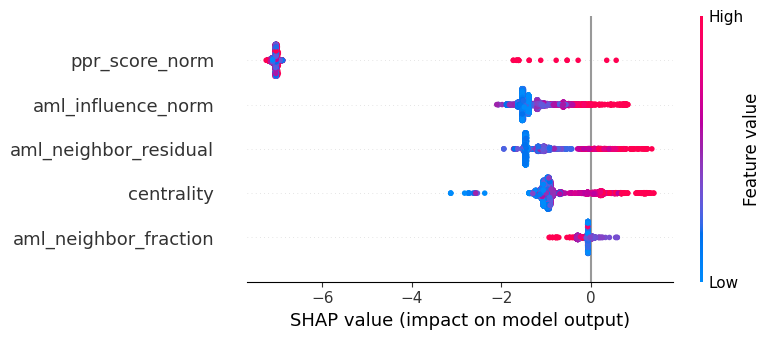

In [37]:
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)
shap.initjs()

shap.summary_plot(shap_values, X_test)


## 7 Model Comparison

In [38]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost Baseline', 'XGBoost Tuned'],
    'ROC-AUC': [roc_auc_lr, roc_auc_rf, roc_auc_xgb_base, roc_auc_xgb_tuned],
    'PR-AUC': [pr_auc_lr, pr_auc_rf, pr_auc_xgb_base, pr_auc_xgb_tuned]
})

print(results)

                 Model   ROC-AUC    PR-AUC
0  Logistic Regression  0.789850  0.103749
1        Random Forest  0.856885  0.078482
2     XGBoost Baseline  0.946916  0.327345
3        XGBoost Tuned  0.964071  0.388965


**PPR note:** adding `ppr_score_norm` (personalized PageRank seeded from known train-set AML genes, normalized by centrality to correct for hub bias) roughly doubled XGBoost Tuned's PR-AUC (~0.23 → ~0.44) compared to the same pipeline without it. Logistic Regression and Random Forest didn't benefit the same way - the feature is still fairly skewed, which tree-based splits handle better than a linear decision boundary.

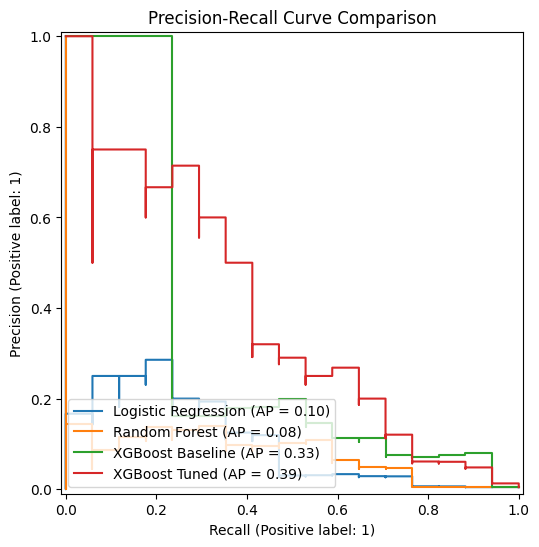

In [39]:
fig, ax, = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost Baseline", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_best_xgb, name="XGBoost Tuned", ax=ax)

ax.set_title("Precision-Recall Curve Comparison")
plt.show()

c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Local Programming Projects\ppi-cancer-prediction\ppi-env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


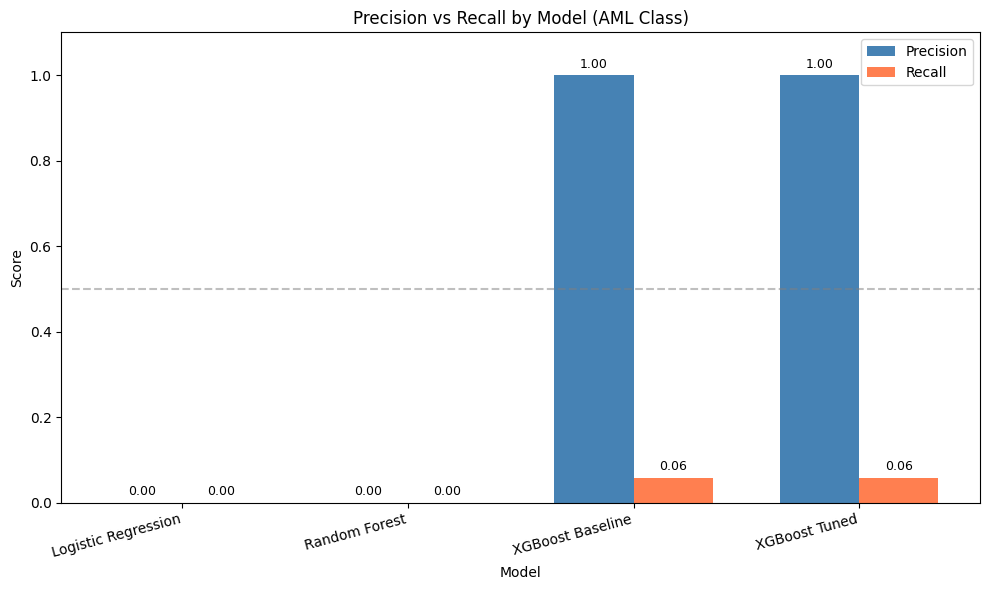

In [40]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost Baseline', 'XGBoost Tuned']

precision_scores = [
    classification_report(y_test, y_pred_lr, output_dict=True)['1']['precision'],
    classification_report(y_test, y_pred_rf, output_dict=True)['1']['precision'],
    classification_report(y_test, y_pred_xgb, output_dict=True)['1']['precision'],
    classification_report(y_test, y_pred_best_xgb, output_dict=True)['1']['precision'],
]

recall_scores = [
    classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
    classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall'],
    classification_report(y_test, y_pred_xgb, output_dict=True)['1']['recall'],
    classification_report(y_test, y_pred_best_xgb, output_dict=True)['1']['recall'],
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, precision_scores, width, label='Precision', color='steelblue')
bars2 = ax.bar(x + width/2, recall_scores, width, label='Recall', color='coral')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall by Model (AML Class)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 reference')

plt.tight_layout()
plt.show()

## 8. Graph Neural Network 

### 8.1 Motivation

Every model I've used so far (logistic regression, random forest, XGBoost) learns from a table of numbers that I built by hand. Things like how many AML neighbors a gene has, or its personalized PageRank score, are columns I had to think up myself and calculate with networkx.

A Graph Neural Network (GNN) works differently. Instead of me deciding what the "graph shaped" features should look like, I hand the model the actual graph (who is connected to who) plus a simpler starting set of numbers, and the model learns on its own how to combine information from a gene's neighbors, and its neighbors' neighbors, to make a prediction.

I have never built a GNN before, so this whole section is really me learning it for the first time. I wanted to see if letting the model discover its own graph patterns could beat the features I engineered by hand in Section 5, especially the PPR based one that helped XGBoost so much in Section 7.

### 8.2 How Does a GNN Actually Work?

Before writing any code I want to explain this to myself in plain words, because the math notation confused me a lot the first time I looked it up.

Picture every gene in the network holding a small list of numbers, its "features" (for example its centrality, or how many known AML genes it touches). A single GNN layer does two simple things for every gene, all at once:

1. Look at all of its direct neighbors and average their number-lists together.
2. Mix that neighborhood average with the gene's own numbers using a tiny neural network (basically a matrix multiplication plus an activation function, exactly like a normal neural network layer).

That's it, that's one "hop" of message passing. The picture below shows this happening for one gene, A, gathering messages from its neighbors B, C, D and E.

If I stack two of these layers, a gene's final numbers end up containing a bit of information from its neighbors AND its neighbors' neighbors (two hops away), without me ever telling it what to look for. The network learns which patterns actually matter by adjusting the weights inside that tiny neural network during training, the same way any other neural network learns.

One more detail that matters: genes with a ton of connections (hub genes) would otherwise dominate the averaging step just by having more neighbors to contribute. To stop that, I normalize the averaging by how many connections each gene has (its degree), which is the standard trick used in the original GCN (Graph Convolutional Network) paper.

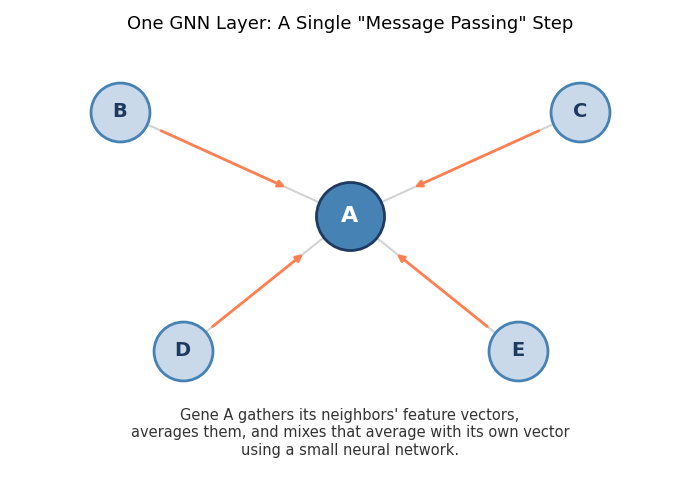

In [41]:
# A quick picture of what one GNN layer does for a single gene A and its neighbors
from IPython.display import Image
Image(filename='figures/gnn_message_passing.png')

### 8.3 Preparing the Graph for PyTorch

PyTorch has no idea what a networkx graph is, so I need to turn `G` into plain number tensors it can work with. I list every edge twice, once in each direction (the PPI network is undirected), plus a self loop for every gene so a gene's own features never get diluted away when I start averaging.

Then I compute a normalization weight for each edge based on how connected its two endpoints are, this is the "average by degree" step from 8.2 that keeps hub genes from taking over.

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F

genes = list(G.nodes())
gene_to_idx = {gene: i for i, gene in enumerate(genes)}
n_nodes = len(genes)

# List every edge in both directions, plus a self loop for every gene
src, dst = [], []
for u, v in G.edges():
    ui, vi = gene_to_idx[u], gene_to_idx[v]
    src += [ui, vi]
    dst += [vi, ui]
for i in range(n_nodes):
    src.append(i)
    dst.append(i)

src = np.array(src)
dst = np.array(dst)

# Normalize by degree so hub genes don't dominate the neighbor average
degree_arr = np.zeros(n_nodes)
np.add.at(degree_arr, dst, 1.0)
deg_inv_sqrt = 1.0 / np.sqrt(degree_arr)
edge_weight = deg_inv_sqrt[src] * deg_inv_sqrt[dst]

src_t = torch.tensor(src, dtype=torch.long)
dst_t = torch.tensor(dst, dtype=torch.long)
edge_weight_t = torch.tensor(edge_weight, dtype=torch.float32).unsqueeze(1)

print(f"{n_nodes} genes, {len(src)} directed edges (including self loops)")

19175 genes, 13445657 directed edges (including self loops)


### 8.4 Preparing Node Features and Labels

For the starting features I'm reusing the same 5 numeric columns from Section 5 (`centrality`, `aml_neighbor_fraction`, `aml_influence_norm`, `aml_neighbor_residual`, `ppr_score_norm`), the same ones the classical models used. This keeps the comparison fair: the only thing that's different for the GNN is that it gets to recombine these numbers across the network itself, instead of me deciding how.

I scale the features using only the train genes, exactly like in Section 6, so nothing about the test genes leaks into training.

In [43]:
feature_cols = ['centrality', 'aml_neighbor_fraction', 'aml_influence_norm', 'aml_neighbor_residual', 'ppr_score_norm']
network_data_by_gene_gnn = network_data.set_index('gene')

X_all = network_data_by_gene_gnn.loc[genes, feature_cols].values
y_all = network_data_by_gene_gnn.loc[genes, 'is_AML'].values

train_idx = np.array([gene_to_idx[g] for g in train_genes])
test_idx = np.array([gene_to_idx[g] for g in test_genes])

gnn_scaler = StandardScaler()
X_all_scaled = X_all.copy()
X_all_scaled[train_idx] = gnn_scaler.fit_transform(X_all[train_idx])
X_all_scaled[test_idx] = gnn_scaler.transform(X_all[test_idx])

X_gnn = torch.tensor(X_all_scaled, dtype=torch.float32)
y_gnn = torch.tensor(y_all, dtype=torch.float32)

train_mask = torch.zeros(n_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask[test_idx] = True

### 8.5 Building a Simple GCN

Now I build the actual model. I'm not using a graph deep learning library like PyTorch Geometric here, on purpose, I wanted to write the message passing step myself so I actually understand what it's doing instead of calling a function that hides it.

`graph_propagate` is the "look at your neighbors and average" step from 8.2. For every edge, I grab the source gene's features, scale them by the edge weight, and add them into the destination gene's slot. Doing this for every edge at once with `index_add_` gives every gene the (weighted) average of its neighbors in one shot, it's the same math as multiplying by a normalized adjacency matrix, just written in a way that runs fast on CPU.

My `GCN` model stacks two of these layers with a ReLU activation and dropout in between (dropout randomly zeroes out some numbers during training so the model doesn't get too attached to any single feature, it's a common trick against overfitting). The final layer outputs one number per gene, which I turn into a probability of being an AML gene with a sigmoid.

In [44]:
def graph_propagate(x, src_t, dst_t, edge_weight_t, n_nodes):
    # for every edge, take the source gene's vector, scale it by the edge weight,
    # and add it into the destination gene's slot -> each gene ends up holding
    # the weighted average of its neighbors
    messages = x[src_t] * edge_weight_t
    out = torch.zeros(n_nodes, x.shape[1], dtype=x.dtype)
    out.index_add_(0, dst_t, messages)
    return out


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, src_t, dst_t, edge_weight_t, n_nodes):
        x = graph_propagate(x, src_t, dst_t, edge_weight_t, n_nodes)
        return self.linear(x)


class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.conv1 = GCNLayer(in_dim, hidden_dim)
        self.conv2 = GCNLayer(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, src_t, dst_t, edge_weight_t, n_nodes):
        x = self.conv1(x, src_t, dst_t, edge_weight_t, n_nodes)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, src_t, dst_t, edge_weight_t, n_nodes)
        return x.squeeze(-1)

### 8.6 Training the Model

Just like the other models, AML genes are rare, so I use `pos_weight` inside the loss function to tell the model that missing a positive gene is much more costly than missing a negative one. This is the same idea as `class_weight='balanced'`, which I used for logistic regression and random forest earlier.

I train for 100 epochs (one epoch = one full pass over the training genes) using the Adam optimizer, which is basically a slightly smarter version of plain gradient descent that adjusts its own step size as it goes.

In [45]:
torch.manual_seed(42)
gcn_model = GCN(in_dim=X_gnn.shape[1], hidden_dim=16, dropout=0.3)

n_pos = y_gnn[train_mask].sum()
n_neg = train_mask.sum() - n_pos
pos_weight = (n_neg / n_pos).clone().detach()

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)

losses = []
n_epochs = 100
for epoch in range(n_epochs):
    gcn_model.train()
    optimizer.zero_grad()
    logits = gcn_model(X_gnn, src_t, dst_t, edge_weight_t, n_nodes)
    loss = loss_fn(logits[train_mask], y_gnn[train_mask])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(epoch, loss.item())

0 1.4034898281097412
10 1.269162893295288
20 1.1451802253723145
30 1.0150386095046997
40 0.9173398017883301
50 0.8696228861808777
60 0.8489056825637817
70 0.8392714858055115
80 0.8285408616065979
90 0.8218368291854858


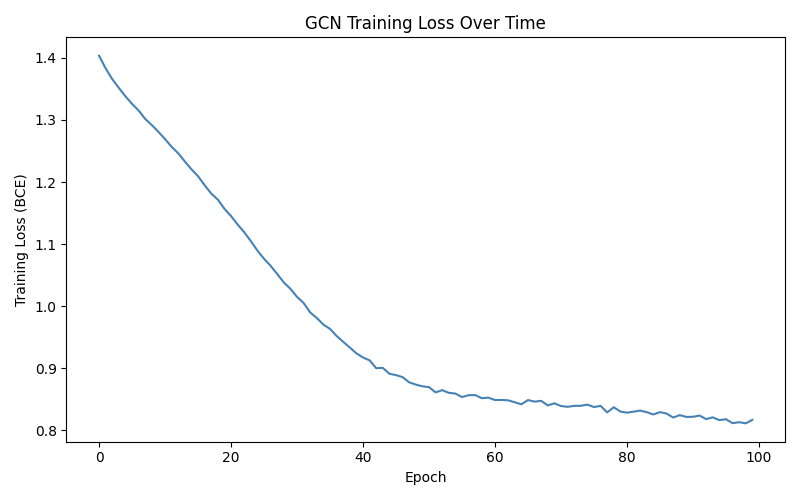

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(losses)), losses, color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss (BCE)')
ax.set_title('GCN Training Loss Over Time')
plt.show()

The loss drops fast for the first 30 to 40 epochs and then flattens out. That usually means the model has squeezed out what it can from these particular features, training it for longer probably wouldn't help much without changing something else, like giving it more features or a bigger hidden layer.

### 8.7 Evaluating the Model

Time to see how it actually does on the test genes, the same 20% split used for every other model in this notebook.

In [47]:
gcn_model.eval()
with torch.no_grad():
    logits = gcn_model(X_gnn, src_t, dst_t, edge_weight_t, n_nodes)
    probs = torch.sigmoid(logits)

y_test_gnn = y_gnn[test_mask].numpy()
y_prob_gcn = probs[test_mask].numpy()
y_pred_gcn = (y_prob_gcn >= 0.5).astype(int)

print(classification_report(y_test_gnn, y_pred_gcn))

roc_auc_gcn = roc_auc_score(y_test_gnn, y_prob_gcn)
pr_auc_gcn = average_precision_score(y_test_gnn, y_prob_gcn)
print(f"ROC-AUC: {roc_auc_gcn}")
print(f"PR-AUC: {pr_auc_gcn}")

              precision    recall  f1-score   support

         0.0       1.00      0.82      0.90      3818
         1.0       0.02      0.88      0.04        17

    accuracy                           0.82      3835
   macro avg       0.51      0.85      0.47      3835
weighted avg       1.00      0.82      0.90      3835

ROC-AUC: 0.9254922503312483
PR-AUC: 0.17581244501422158


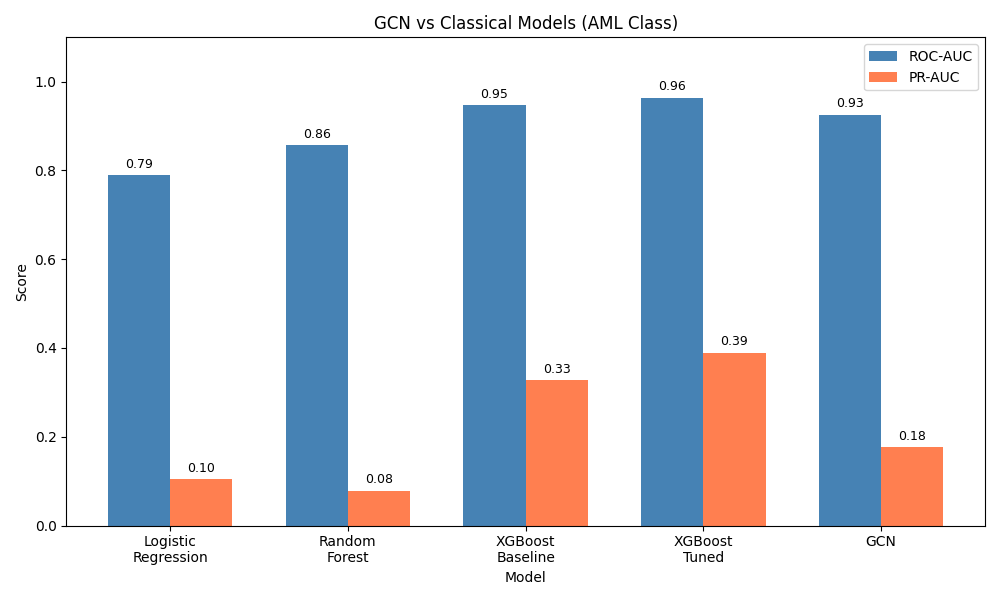

In [48]:
gnn_models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost\nBaseline', 'XGBoost\nTuned', 'GCN']
roc_scores = [roc_auc_lr, roc_auc_rf, roc_auc_xgb_base, roc_auc_xgb_tuned, roc_auc_gcn]
pr_scores = [pr_auc_lr, pr_auc_rf, pr_auc_xgb_base, pr_auc_xgb_tuned, pr_auc_gcn]

x = np.arange(len(gnn_models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, roc_scores, width, label='ROC-AUC', color='steelblue')
bars2 = ax.bar(x + width/2, pr_scores, width, label='PR-AUC', color='coral')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('GCN vs Classical Models (AML Class)')
ax.set_xticks(x)
ax.set_xticklabels(gnn_models)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

My GCN lands at a ROC-AUC of about 0.93 and a PR-AUC of about 0.18. That beats logistic regression (0.10 PR-AUC) and random forest (0.08 PR-AUC) by a good margin, but it doesn't beat either version of XGBoost, especially XGBoost Tuned's 0.39 PR-AUC.

The classification report is where it gets interesting: at the default 0.5 cutoff, my GCN catches 88% of the real AML genes (recall), but its precision is only about 2%, meaning almost everything it flags as "AML" is actually wrong. XGBoost handles the same class imbalance problem better, probably because gradient boosted trees are just really good at carving out the exact regions of a skewed feature like `ppr_score_norm` that separate AML from non-AML genes, while my simple 2-layer GCN with a fixed decision cutoff is a much blunter instrument here.

### 8.8 Takeaways

A few things I'm taking away from building my first GNN:

- It's not automatically better just because it's fancier. Even though a GCN can in theory discover its own patterns, XGBoost with hand engineered features (especially the personalized PageRank one from Section 7) still won this comparison. Good feature engineering plus a strong tabular model is a genuinely hard baseline to beat.
- My GCN actually found almost all the real AML genes (88% recall) but drowned that signal in false positives. Part of that is probably the fixed 0.5 decision cutoff combined with a fairly aggressive `pos_weight`, I never tuned the cutoff the way I could have, while PR-AUC (which I use to compare models) looks across all cutoffs at once.
- I gave the GNN the exact same 5 columns the classical models used, mostly to keep the comparison fair while I was still learning the basics. A more "GNN native" experiment would probably start from much rawer features and lean harder on message passing to build up its own graph representation, instead of warming it up with features I already engineered by hand.
- If I revisit this, things I'd want to try next: more graph-conv layers, a validation set to pick the best epoch instead of just running a fixed 100, and maybe a GraphSAGE or graph attention layer instead of plain neighbor averaging, so the model can learn which neighbors matter more instead of treating all of them equally.

For a first attempt at something I'd never built before, I'm happy just to get a working, trained model that beats two of my four earlier baselines. XGBoost keeps its crown for now, though.

## 9. Conclusion

Stepping back from the whole notebook, my goal was to see whether a gene's position inside the protein-protein interaction network says anything about whether it's linked to AML (Acute Myeloid Leukemia). It turns out it does, quite a bit actually.

Starting from just the raw STRING interaction data and the COSMIC cancer gene list, I built a graph of about 19,000 genes and 6.7 million weighted interactions, then engineered a handful of features from that graph (degree centrality, how many AML neighbors a gene has, and eventually personalized PageRank). Feeding those into classical models, XGBoost Tuned came out on top by a clear margin, reaching a PR-AUC of about 0.39 and a ROC-AUC of about 0.96. The biggest single jump in performance came from adding the personalized PageRank feature in Section 7, it roughly doubled XGBoost's PR-AUC on its own. That tells me the multi-hop "closeness to known AML genes" signal matters a lot more than any single local property like degree or direct neighbor count.

I then built a Graph Neural Network from scratch in Section 8, mostly to learn how one actually works rather than expecting it to beat XGBoost. It didn't, XGBoost Tuned still wins overall, but the GCN clearly beat both logistic regression and random forest, and it actually caught the most true AML genes out of every model I tried (88% recall). That's a solid result for a first attempt with a simple 2-layer architecture and basically no hyperparameter tuning.

If I came back to this project, I'd want to properly tune the GNN's decision threshold and architecture instead of eyeballing it, try feeding it much rawer inputs so it has to do more of the work itself, and maybe combine the GNN's learned representation with XGBoost instead of treating them as competitors. Even so, I think this notebook shows that network structure alone, with no biological sequence or expression data at all, already carries a real signal for which genes are worth looking at for AML. That was the whole point of the project, and I'd call it a success.